In [1]:
import pandas as pd
import numpy as np

In [2]:
sales_df = pd.read_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\raw\M5\sales_train_validation.csv"
)

calendar_df = pd.read_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\raw\M5\calendar.csv"
)

price_df = pd.read_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\raw\M5\sell_prices.csv"
)

In [3]:
print("Sales Shape:", sales_df.shape)
print("Calendar Shape:", calendar_df.shape)
print("Price Shape:", price_df.shape)

Sales Shape: (30490, 1919)
Calendar Shape: (1969, 14)
Price Shape: (6841121, 4)


In [4]:
sales_df.columns[:10]

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4'],
      dtype='object')

In [5]:
sales_df.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4',
       ...
       'd_1904', 'd_1905', 'd_1906', 'd_1907', 'd_1908', 'd_1909', 'd_1910',
       'd_1911', 'd_1912', 'd_1913'],
      dtype='object', length=1919)

In [6]:
sales_df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [7]:
# Aggregate total sales across all products

daily_sales = sales_df.iloc[:, 6:].sum(axis=0)

daily_sales = daily_sales.reset_index()


daily_sales.columns = [
    "d",
    "sales"
]

In [8]:
print(daily_sales.head())
print(daily_sales.columns)

     d  sales
0  d_1  32631
1  d_2  31749
2  d_3  23783
3  d_4  25412
4  d_5  19146
Index(['d', 'sales'], dtype='object')


In [9]:
daily_sales.columns = [
    "d",
    "sales"
]

In [10]:
daily_sales.head()

,d,sales
0,d_1,32631
1,d_2,31749
2,d_3,23783
3,d_4,25412
4,d_5,19146


In [11]:
# Merge calendar information
daily_sales = daily_sales.merge(
    calendar_df,
    on="d",
    how="left"
)

In [12]:
daily_sales.shape

(1913, 15)

In [13]:
daily_sales.head()

,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,d_1,32631,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,d_2,31749,2011-01-30,11101,Sunday,2,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,d_3,23783,2011-01-31,11101,Monday,3,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,d_4,25412,2011-02-01,11101,Tuesday,4,2,2011,NaN,NaN,NaN,NaN,1,1,0
4,d_5,19146,2011-02-02,11101,Wednesday,5,2,2011,NaN,NaN,NaN,NaN,1,0,1


In [14]:
# Convert date column
daily_sales["date"] = pd.to_datetime(
    daily_sales["date"]
)

daily_sales = daily_sales.sort_values(
    "date"
)

In [15]:
daily_sales.head()

,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,d_1,32631,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,d_2,31749,2011-01-30,11101,Sunday,2,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,d_3,23783,2011-01-31,11101,Monday,3,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,d_4,25412,2011-02-01,11101,Tuesday,4,2,2011,NaN,NaN,NaN,NaN,1,1,0
4,d_5,19146,2011-02-02,11101,Wednesday,5,2,2011,NaN,NaN,NaN,NaN,1,0,1


In [16]:
daily_sales.shape

(1913, 15)

In [17]:
daily_sales["lag_7"] = (
    daily_sales["sales"].shift(7)
)

In [18]:
daily_sales["lag_28"] = (
    daily_sales["sales"].shift(28)
)

In [19]:
daily_sales["rolling_mean_7"] = (
    daily_sales["sales"]
    .shift(1)
    .rolling(7)
    .mean()
)

In [20]:
daily_sales["rolling_mean_28"] = (
    daily_sales["sales"]
    .shift(1)
    .rolling(28)
    .mean()
)

In [21]:
daily_sales["day_of_week"] = (
    daily_sales["date"].dt.dayofweek
)

daily_sales["month"] = (
    daily_sales["date"].dt.month
)

daily_sales["year"] = (
    daily_sales["date"].dt.year
)

daily_sales["week"] = (
    daily_sales["date"].dt.isocalendar().week
)

In [22]:
# Holiday / event indicator
daily_sales["is_event"] = (
    daily_sales["event_name_1"]
    .notnull()
    .astype(int)
)

In [23]:
daily_sales[
    [
        "date",
        "sales",
        "lag_7",
        "lag_28",
        "rolling_mean_7",
        "rolling_mean_28"
    ]
].head(40)

,date,sales,lag_7,lag_28,rolling_mean_7,rolling_mean_28
0,2011-01-29,32631,NaN,NaN,NaN,NaN
1,2011-01-30,31749,NaN,NaN,NaN,NaN
2,2011-01-31,23783,NaN,NaN,NaN,NaN
3,2011-02-01,25412,NaN,NaN,NaN,NaN
4,2011-02-02,19146,NaN,NaN,NaN,NaN
5,2011-02-03,29211,NaN,NaN,NaN,NaN
6,2011-02-04,28010,NaN,NaN,NaN,NaN
7,2011-02-05,37932,32631.0,NaN,27134.571429,NaN
8,2011-02-06,32736,31749.0,NaN,27891.857143,NaN
9,2011-02-07,25572,23783.0,NaN,28032.857143,NaN


In [24]:
daily_sales[
    [
        "lag_7",
        "lag_28",
        "rolling_mean_7",
        "rolling_mean_28"
    ]
].notnull().sum()

lag_7              1906
lag_28             1885
rolling_mean_7     1906
rolling_mean_28    1885
dtype: int64

In [25]:
daily_sales.isnull().sum()

d                     0
sales                 0
date                  0
wm_yr_wk              0
weekday               0
wday                  0
month                 0
year                  0
event_name_1       1759
event_type_1       1759
event_name_2       1909
event_type_2       1909
snap_CA               0
snap_TX               0
snap_WI               0
lag_7                 7
lag_28               28
rolling_mean_7        7
rolling_mean_28      28
day_of_week           0
week                  0
is_event              0
dtype: int64

In [26]:
# daily_sales = daily_sales.dropna()
daily_sales_clean = daily_sales.dropna(
    subset=[
        "lag_7",
        "lag_28",
        "rolling_mean_7",
        "rolling_mean_28"
    ]
)

In [27]:
daily_sales_clean.shape

(1885, 22)

In [28]:
daily_sales_clean.to_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\daily_business_sales.csv",
    index=False
)

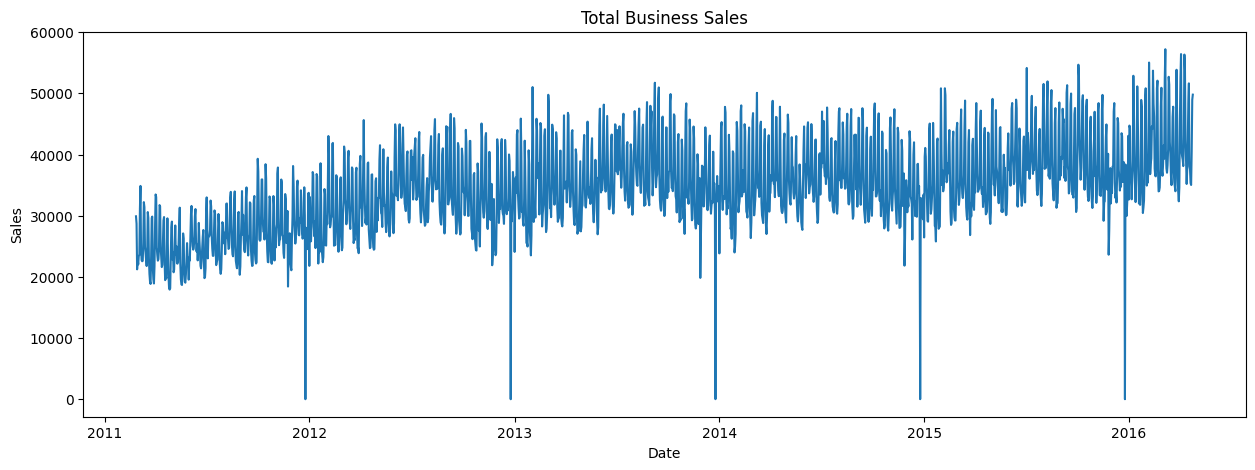

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    daily_sales_clean["date"],
    daily_sales_clean["sales"]
)

plt.title("Total Business Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()